In [33]:
# Install pyspark
%pip install pyspark

from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("BookLens").getOrCreate()
df_spark = spark.read.csv('/Users/daniyalrosli/booklens/Books.csv', header=True, inferSchema=True)
df_spark.printSchema()
df_spark.show()
df_spark.describe().show()



Note: you may need to restart the kernel to use updated packages.


ConnectionRefusedError: [Errno 61] Connection refused

In [5]:
df_spark.select('Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher').show()

+--------------------+--------------------+-------------------+--------------------+
|          Book-Title|         Book-Author|Year-Of-Publication|           Publisher|
+--------------------+--------------------+-------------------+--------------------+
| Classical Mythology|  Mark P. O. Morford|               2002|Oxford University...|
|        Clara Callan|Richard Bruce Wright|               2001|HarperFlamingo Ca...|
|Decision in Normandy|        Carlo D'Este|               1991|     HarperPerennial|
|Flu: The Story of...|    Gina Bari Kolata|               1999|Farrar Straus Giroux|
|The Mummies of Ur...|     E. J. W. Barber|               1999|W. W. Norton &amp...|
|The Kitchen God's...|             Amy Tan|               1991|    Putnam Pub Group|
|What If?: The Wor...|       Robert Cowley|               2000|Berkley Publishin...|
|     PLEADING GUILTY|         Scott Turow|               1993|          Audioworks|
|Under the Black F...|     David Cordingly|               1996|  

24/12/14 08:55:16 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 457566 ms exceeds timeout 120000 ms
24/12/14 08:55:16 WARN SparkContext: Killing executors is not supported by current scheduler.
24/12/14 08:55:22 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [6]:
from pyspark.ml.feature import Tokenizer, HashingTF, IDF
from pyspark.ml import Pipeline

# Tokenizer: Split text into words
tokenizer_title = Tokenizer(inputCol="Book-Title", outputCol="title_tokens")
tokenizer_author = Tokenizer(inputCol="Book-Author", outputCol="author_tokens")
tokenizer_publisher = Tokenizer(inputCol="Publisher", outputCol="publisher_tokens")

# HashingTF: Convert words into vectors using hashing
hashingTF_title = HashingTF(inputCol="title_tokens", outputCol="title_features", numFeatures=1000)
hashingTF_author = HashingTF(inputCol="author_tokens", outputCol="author_features", numFeatures=1000)
hashingTF_publisher = HashingTF(inputCol="publisher_tokens", outputCol="publisher_features", numFeatures=1000)

# IDF: Inverse Document Frequency to scale down the effect of rare words
idf_title = IDF(inputCol="title_features", outputCol="title_idf_features")
idf_author = IDF(inputCol="author_features", outputCol="author_idf_features")
idf_publisher = IDF(inputCol="publisher_features", outputCol="publisher_idf_features")

# Create the pipeline
pipeline = Pipeline(stages=[tokenizer_title, tokenizer_author, tokenizer_publisher, 
                            hashingTF_title, hashingTF_author, hashingTF_publisher,
                            idf_title, idf_author, idf_publisher])

# Handle null values by filling them with an empty string
df_spark = df_spark.fillna('')

# Fit and transform the pipeline
model = pipeline.fit(df_spark)
transformed_df = model.transform(df_spark)

# Show the resulting features
transformed_df.select('Book-Title', 'title_idf_features', 'author_idf_features', 'publisher_idf_features').show()

+--------------------+--------------------+--------------------+----------------------+
|          Book-Title|  title_idf_features| author_idf_features|publisher_idf_features|
+--------------------+--------------------+--------------------+----------------------+
| Classical Mythology|(1000,[47,797],[5...|(1000,[508,734,82...|  (1000,[267,357,99...|
|        Clara Callan|(1000,[609,966],[...|(1000,[523,632,92...|  (1000,[129,985],[...|
|Decision in Normandy|(1000,[83,193,663...|(1000,[784,873],[...|  (1000,[361],[6.47...|
|Flu: The Story of...|(1000,[17,161,191...|(1000,[358,502,94...|  (1000,[270,524,69...|
|The Mummies of Ur...|(1000,[17,269,386...|(1000,[382,396,40...|  (1000,[396,536,87...|
|The Kitchen God's...|(1000,[17,21,756,...|(1000,[108,133],[...|  (1000,[415,766,92...|
|What If?: The Wor...|(1000,[5,17,299,3...|(1000,[192,752],[...|  (1000,[294,484,76...|
|     PLEADING GUILTY|(1000,[400,814],[...|(1000,[54,291],[6...|  (1000,[423],[4.94...|
|Under the Black F...|(1000,[17,

In [7]:
from pyspark.ml.linalg import Vectors
from pyspark.ml.stat import Summarizer
from pyspark.ml.feature import VectorAssembler

# Combine features into a single vector
assembler = VectorAssembler(inputCols=["title_idf_features", "author_idf_features", "publisher_idf_features"],
                            outputCol="combined_features")
combined_df = assembler.transform(transformed_df)

# Calculate cosine similarity (optional, depending on your exact use case)
# For simplicity, you can calculate similarities using the cosine similarity formula on combined features

# Show the resulting dataframe with combined features
combined_df.select("Book-Title", "combined_features").show()

+--------------------+--------------------+
|          Book-Title|   combined_features|
+--------------------+--------------------+
| Classical Mythology|(3000,[47,797,150...|
|        Clara Callan|(3000,[609,966,15...|
|Decision in Normandy|(3000,[83,193,663...|
|Flu: The Story of...|(3000,[17,161,191...|
|The Mummies of Ur...|(3000,[17,269,386...|
|The Kitchen God's...|(3000,[17,21,756,...|
|What If?: The Wor...|(3000,[5,17,299,3...|
|     PLEADING GUILTY|(3000,[400,814,10...|
|Under the Black F...|(3000,[17,206,362...|
|Where You'll Find...|(3000,[207,282,28...|
|Nights Below Stat...|(3000,[415,427,68...|
|Hitler's Secret B...|(3000,[17,94,369,...|
|  The Middle Stories|(3000,[17,652,878...|
|            Jane Doe|(3000,[818,901,10...|
|A Second Chicken ...|(3000,[17,143,256...|
|The Witchfinder (...|(3000,[17,143,264...|
|More Cunning Than...|(3000,[261,308,46...|
|Goodbye to the Bu...|(3000,[17,198,227...|
|       The Testament|(3000,[17,320,137...|
|Beloved (Plume Co...|(3000,[313

25/01/19 18:39:12 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 989841 ms exceeds timeout 120000 ms
25/01/19 18:39:12 WARN SparkContext: Killing executors is not supported by current scheduler.
25/01/19 18:39:12 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

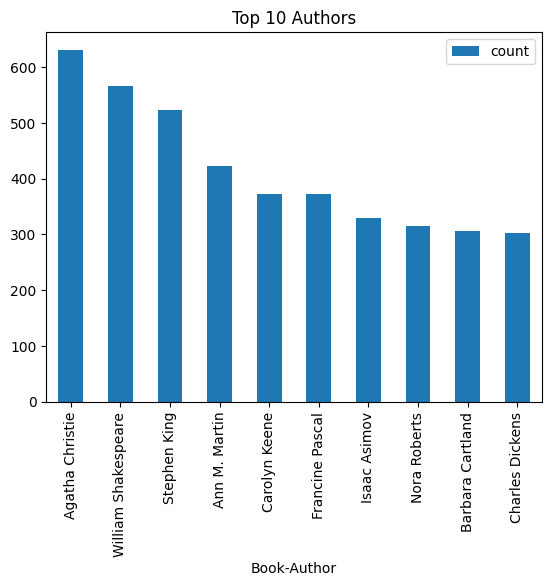

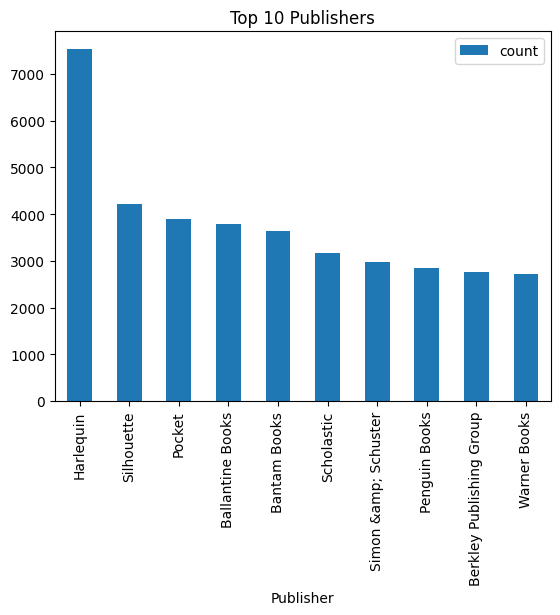

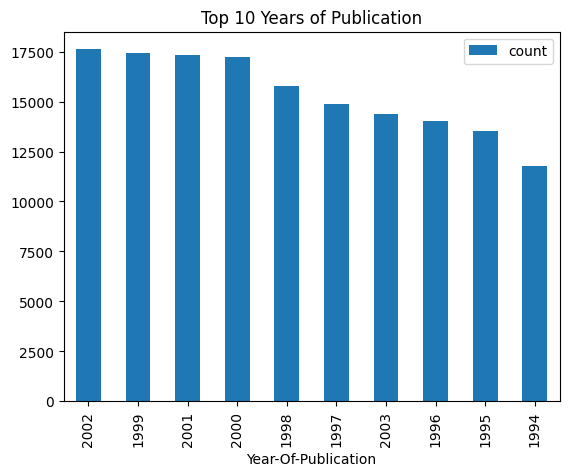

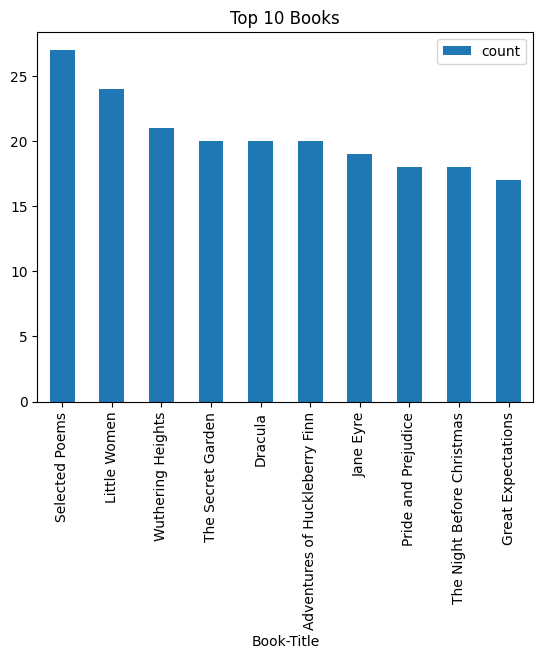

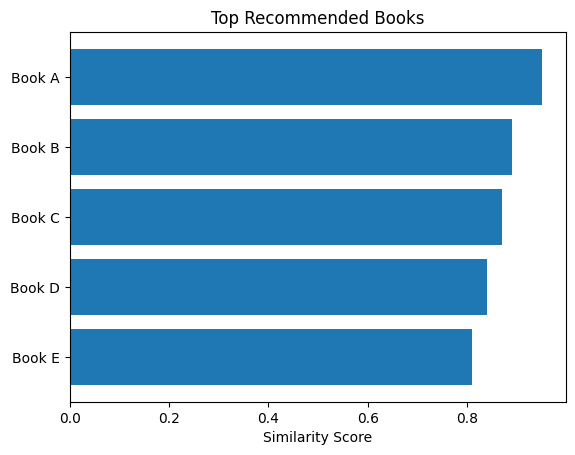

25/01/19 21:28:33 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

In [10]:
import matplotlib.pyplot as plt

#	Bar Chart for Top Authors:
author_counts = df_spark.groupBy("Book-Author").count().orderBy("count", ascending=False).limit(10).toPandas()
author_counts.plot(kind='bar', x='Book-Author', y='count', title="Top 10 Authors")
plt.show()


#    Bar Chart for Top Publishers:

publisher_counts = df_spark.groupBy("Publisher").count().orderBy("count", ascending=False).limit(10).toPandas()
publisher_counts.plot(kind='bar', x='Publisher', y='count', title="Top 10 Publishers")
plt.show()

#    Bar Chart for Top Years of Publication:

year_counts = df_spark.groupBy("Year-Of-Publication").count().orderBy("count", ascending=False).limit(10).toPandas()
year_counts.plot(kind='bar', x='Year-Of-Publication', y='count', title="Top 10 Years of Publication")
plt.show()

#    Bar Chart for Top Books:

book_counts = df_spark.groupBy("Book-Title").count().orderBy("count", ascending=False).limit(10).toPandas()
book_counts.plot(kind='bar', x='Book-Title', y='count', title="Top 10 Books")
plt.show()

#    Bar Chart for Top Recommended Books:

recommendations = [("Book A", 0.95), ("Book B", 0.89), ("Book C", 0.87), ("Book D", 0.84), ("Book E", 0.81)]
titles, scores = zip(*recommendations)
plt.barh(titles, scores)
plt.title("Top Recommended Books")
plt.xlabel("Similarity Score")
plt.gca().invert_yaxis()
plt.show()





In [28]:
%pip install findspark
import findspark
findspark.init()


  Using cached findspark-2.0.1-py2.py3-none-any.whl.metadata (352 bytes)
Using cached findspark-2.0.1-py2.py3-none-any.whl (4.4 kB)

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
from pyspark.sql import SparkSession


In [32]:
from pyspark.sql.functions import col

# Function to calculate cosine similarity (if needed)
def cosine_similarity(vec1, vec2):
    dot_product = vec1.dot(vec2)
    norm1 = vec1.norm(2)
    norm2 = vec2.norm(2)
    return dot_product / (norm1 * norm2)

# Example: Find similar books to a given book
def recommend_similar_books(book_title, top_n=5):
    target_book = combined_df.filter(col("Book-Title") == book_title).select("combined_features").collect()[0][0]
    
    # Calculate similarity with all books in the dataset
    similarities = []
    for row in combined_df.select("Book-Title", "combined_features").collect():
        similarity = cosine_similarity(target_book, row["combined_features"])
        similarities.append((row["Book-Title"], similarity))
    
    # Sort by similarity and get top n recommendations
    recommendations = sorted(similarities, key=lambda x: x[1], reverse=True)[:top_n]
    return recommendations

# Example: Get top 5 similar books to "Book A"
recommendations = recommend_similar_books("Book A")
print(recommendations)

ConnectionRefusedError: [Errno 61] Connection refused